# EDA Interactive Notebook
# # 📊 Retail Exploratory Data Analysis

---

### How to use this notebook
Run cells from top to bottom using **Shift+Enter**.
Each cell has a comment explaining what it does and why.

This notebook is the **interactive layer** on top of `run.py`.
While `run.py` produces text reports, this notebook produces:
- Visual charts (histograms, box plots, scatter plots, heatmaps)
- Interactive exploration of specific findings
- Deeper investigation of anomalies

**Business questions we answer here:**
## Business Questions

### Question 1 — Revenue Performance
Which product categories and stores generate the highest revenue per sale?  
Which stores are underperforming relative to their category average?

> Answered using `groupby` rankings and `vs_category_avg` comparisons.  
> A negative `vs_category_avg` value flags an underperforming store.

---

### Question 2 — Discount Impact
Does offering higher discounts actually drive higher sales volume?  
Compute the **Pearson correlation** between `discount_pct` and `total_amount`.

> A negative correlation means higher discounts produce lower revenue totals —  
> the company is sacrificing margin without increasing sales.

---

### Question 3 — Anomaly Detection
Which transactions are statistically unusual?  
Use **IQR + Z-score consensus** to identify outliers and save them to `reports/anomalies.csv`.

> A transaction is flagged only when both methods agree — reducing false positives.



In [3]:
# ── Cell 1: Imports and Setup ─────────────────────────────────────────────
# Before anything else, we import the libraries we need.
# These are the standard imports for any EDA notebook.

import sys
import pathlib
import numpy as np

# Add the project root to Python path so we can import our classes
# pathlib.Path.cwd() returns the current working directory
# We walk up until we find config.py
_root = pathlib.Path.cwd()
while not (_root / 'config.py').exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # matplotlib: the core Python plotting library
import seaborn as sns             # seaborn: statistical plots built on matplotlib

# Tell matplotlib to display plots directly in the notebook (not in a separate window)



# Set seaborn style: 'whitegrid' adds a subtle grid which makes values easier to read
sns.set_style('whitegrid')

# Set figure size default: (width_inches, height_inches)
plt.rcParams['figure.figsize'] = (12, 5)

# Import our pipeline classes
from config import DATA_PATH, REPORTS_DIR, INDUSTRY
from src.eda_engine import EDAEngine
from src.anomaly_detector import AnomalyDetector
print(f'Setup complete. Industry: {INDUSTRY}')
print(f'Data file: {DATA_PATH}')


Setup complete. Industry: retail
Data file: /Users/samueladesina/retail-eda-analysis/data/processed-data.csv


In [4]:
# ── Cell 2: Load and Profile the Data ────────────────────────────────────
# We use our EDAEngine class to load and profile the data.
# This is the same code that run.py executes — but here we can
# inspect intermediate results interactively.

engine = EDAEngine()
engine.load().profile()

# Access the profile results dictionary directly
p = engine.results['profile']

print('=' * 50)
print('  DATASET OVERVIEW')
print('=' * 50)
print(f'  Rows:          {p["rows"]:,}')
print(f'  Columns:       {p["columns"]}')
print(f'  Numeric cols:  {p["numeric_cols"]}')
print(f'  Text cols:     {p["categorical_cols"]}')
print(f'  Missing vals:  {p["total_nulls"]:,} ({p["null_pct"]}%)')
print(f'  Memory:        {p["memory_mb"]} MB')

2026-05-16 23:38:32 [INFO] EDAEngine initialised — industry: retail
2026-05-16 23:38:32 [INFO] [EDA] Loading: processed-data.csv
2026-05-16 23:38:33 [INFO] [EDA] Loaded 50,243 rows × 33 columns
2026-05-16 23:38:33 [INFO] [EDA] Column types: 12 numeric, 14 categorical
2026-05-16 23:38:33 [INFO] [EDA] Computing dataset profile...
2026-05-16 23:38:34 [INFO] [EDA] Profile complete — 50,243 rows | 0.0% nulls


  DATASET OVERVIEW
  Rows:          50,243
  Columns:       33
  Numeric cols:  12
  Text cols:     14
  Missing vals:  0 (0.0%)
  Memory:        59.21 MB


In [5]:
# ── Cell 3: Descriptive Statistics ───────────────────────────────────────
# pandas .describe() gives us the 8 key statistics for every numeric column.
# We display it as a formatted table directly in the notebook.

# Select only columns that are not pipeline metadata (starting with _)
analysis_df = engine.df.drop(
    columns=[c for c in engine.df.columns if c.startswith('_')],
    errors='ignore'
)

# .describe() → count, mean, std, min, 25%, 50%, 75%, max for each numeric col
# .T transposes the table: columns become rows (easier to read with many columns)
# .style.background_gradient() adds colour — higher values are darker blue
desc = analysis_df.describe().round(2).T
desc

,count,mean,std,min,25%,50%,75%,max
sale_id,50243.0,24995.56,14439.15,1.00,12482.50,25002.00,37502.50,50007.00
quantity,50243.0,5.50,2.88,1.00,3.00,5.00,8.00,10.00
unit_price,50243.0,997.46,577.31,1.08,500.28,994.38,1498.92,1999.99
discount_pct,50243.0,7.04,7.27,0.00,0.00,5.00,15.00,20.00
total_amount,50243.0,5065.01,4274.88,-8664.95,1619.51,3889.74,7546.58,99999.99
product_id,50243.0,498.41,288.72,1.00,249.00,498.00,747.00,1000.00
unit_cost,50243.0,187.68,278.68,1.61,12.85,38.80,209.05,1393.61
margin_pct,50243.0,57.63,14.63,14.17,49.97,61.22,68.83,81.03
store_id,50243.0,6.98,3.74,1.00,4.00,7.00,10.00,13.00
sqft,50243.0,11594.21,3984.57,5000.00,9500.00,11000.00,13000.00,20000.00


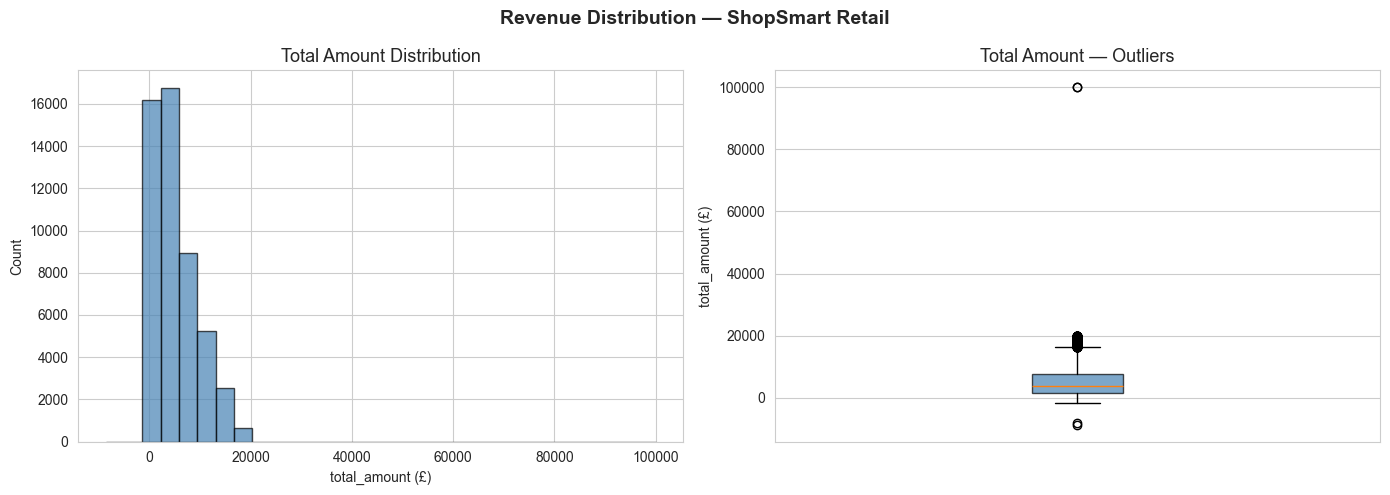

Saved → reports/dist_total_amount.png


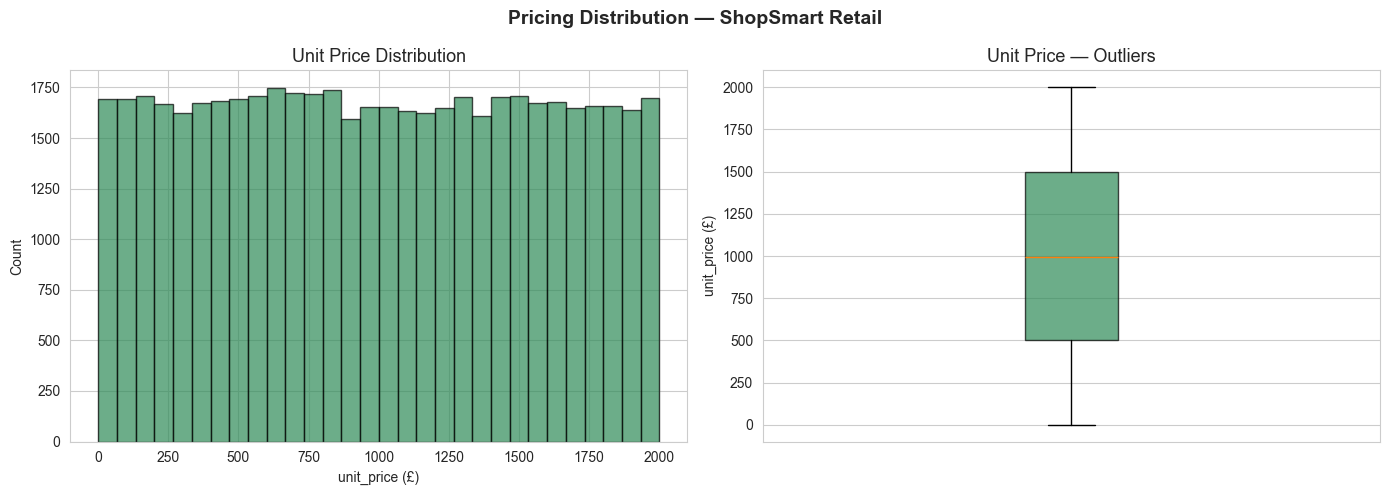

Saved → reports/dist_unit_price.png


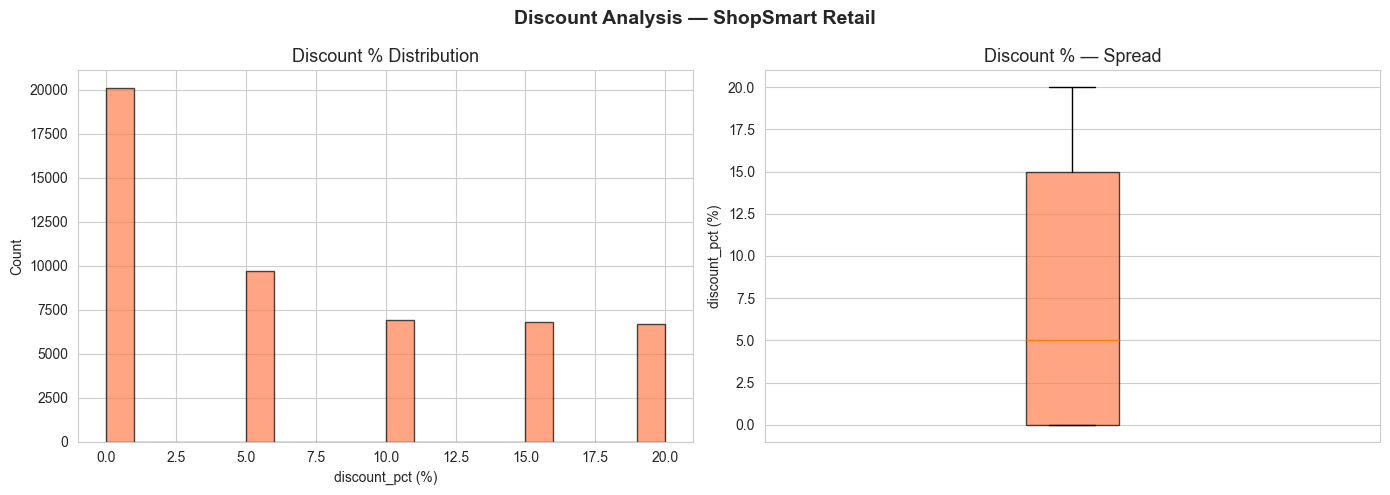

Saved → reports/dist_discount_pct.png


In [14]:
import numpy as np

# ── Total Amount Distribution — Histogram & Boxplot ──────────────────────
if 'total_amount' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['total_amount'].dropna(),
        bins=30,
        color='steelblue',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Total Amount Distribution', fontsize=13)
    axes[0].set_xlabel('total_amount (£)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['total_amount'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7)
    )
    axes[1].set_title('Total Amount — Outliers', fontsize=13)
    axes[1].set_ylabel('total_amount (£)')
    axes[1].set_xticks([])

    plt.suptitle('Revenue Distribution — ShopSmart Retail', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'dist_total_amount.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/dist_total_amount.png')

# ── Unit Price Distribution ───────────────────────────────────────────────
if 'unit_price' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['unit_price'].dropna(),
        bins=30,
        color='seagreen',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Unit Price Distribution', fontsize=13)
    axes[0].set_xlabel('unit_price (£)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['unit_price'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='seagreen', alpha=0.7)
    )
    axes[1].set_title('Unit Price — Outliers', fontsize=13)
    axes[1].set_ylabel('unit_price (£)')
    axes[1].set_xticks([])

    plt.suptitle('Pricing Distribution — ShopSmart Retail', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'dist_unit_price.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/dist_unit_price.png')

# ── Discount % Distribution ───────────────────────────────────────────────
if 'discount_pct' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        analysis_df['discount_pct'].dropna(),
        bins=20,
        color='coral',
        alpha=0.7,
        edgecolor='black'
    )
    axes[0].set_title('Discount % Distribution', fontsize=13)
    axes[0].set_xlabel('discount_pct (%)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(
        analysis_df['discount_pct'].dropna(),
        vert=True,
        patch_artist=True,
        boxprops=dict(facecolor='coral', alpha=0.7)
    )
    axes[1].set_title('Discount % — Spread', fontsize=13)
    axes[1].set_ylabel('discount_pct (%)')
    axes[1].set_xticks([])

    plt.suptitle('Discount Analysis — ShopSmart Retail', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'dist_discount_pct.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/dist_discount_pct.png')

2026-05-17 00:05:21 [INFO] [EDA] Running group analysis...
2026-05-17 00:05:21 [INFO] [EDA] Group analysis: 2 grouping variables


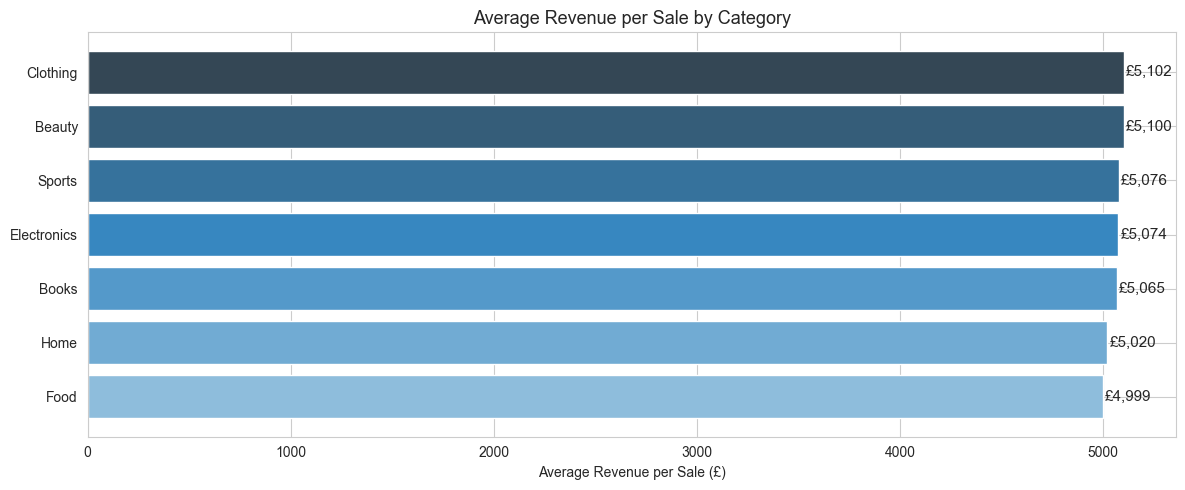

CATEGORY RANKING — Highest Revenue per Sale
      Category  Avg Revenue per Sale (£)
1     Clothing                   5102.32
2       Beauty                   5100.17
3       Sports                   5076.35
4  Electronics                   5073.70
5        Books                   5065.47
6         Home                   5020.31
7         Food                   4998.85


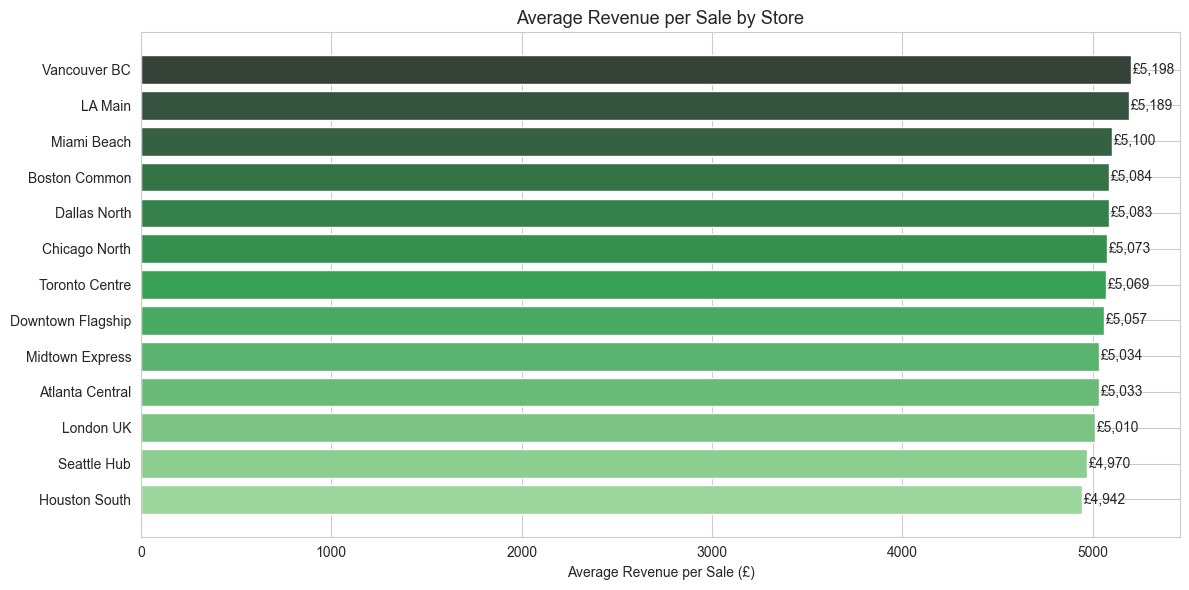


STORE RANKING — Highest Revenue per Sale
                Store  Avg Revenue per Sale (£)
1        Vancouver BC                   5198.48
2             LA Main                   5188.53
3         Miami Beach                   5100.03
4       Boston Common                   5084.25
5        Dallas North                   5083.42
6       Chicago North                   5073.50
7      Toronto Centre                   5068.66
8   Downtown Flagship                   5056.88
9     Midtown Express                   5033.74
10    Atlanta Central                   5032.51
11          London UK                   5010.35
12        Seattle Hub                   4970.23
13      Houston South                   4942.07


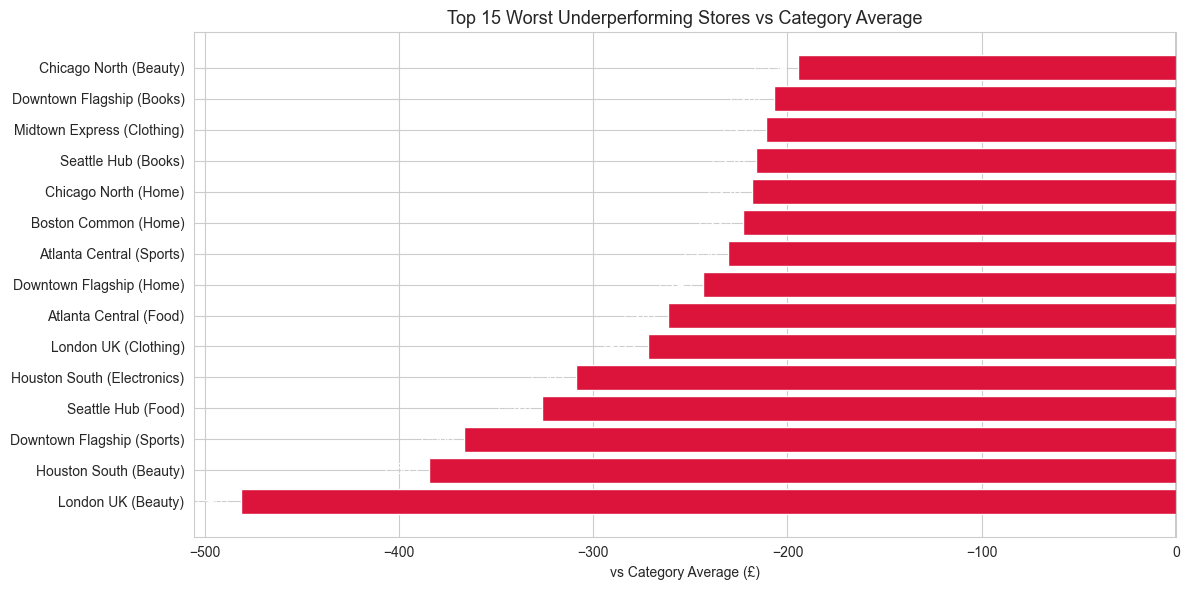


Top 15 worst underperforming store-category combinations:
       store_name    category  avg_per_sale  category_avg  vs_category_avg
        London UK      Beauty   4618.854813   5100.166812          -481.31
    Houston South      Beauty   4715.653689   5100.166812          -384.51
Downtown Flagship      Sports   4710.114678   5076.354435          -366.24
      Seattle Hub        Food   4672.554526   4998.846624          -326.29
    Houston South Electronics   4764.609886   5073.702256          -309.09
        London UK    Clothing   4830.445145   5102.316647          -271.87
  Atlanta Central        Food   4737.455052   4998.846624          -261.39
Downtown Flagship        Home   4776.921528   5020.306214          -243.38
  Atlanta Central      Sports   4845.858505   5076.354435          -230.50
    Boston Common        Home   4797.305747   5020.306214          -223.00
    Chicago North        Home   4801.888726   5020.306214          -218.42
      Seattle Hub       Books   4849.4898

In [13]:
# ── Cell 5: Q1 — Revenue Performance ─────────────────────────────────────
# Which product categories and stores generate the highest revenue per sale?
# Which stores are underperforming relative to their category average?

engine.group_analysis()

# ── Q1a: Top Categories by Revenue per Sale ───────────────────────────────
category_revenue = (
    analysis_df.groupby('category')['total_amount']
    .mean()
    .reset_index()
    .rename(columns={'total_amount': 'avg_revenue_per_sale'})
    .sort_values('avg_revenue_per_sale', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    category_revenue['category'],
    category_revenue['avg_revenue_per_sale'],
    color=sns.color_palette('Blues_d', len(category_revenue))
)

for bar, val in zip(bars, category_revenue['avg_revenue_per_sale']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'£{val:,.0f}', va='center', fontsize=11)

ax.set_title('Average Revenue per Sale by Category', fontsize=13)
ax.set_xlabel('Average Revenue per Sale (£)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'q1_category_revenue_per_sale.png', dpi=150, bbox_inches='tight')
plt.show()

category_revenue_ranked = (
    category_revenue
    .sort_values('avg_revenue_per_sale', ascending=False)
    .reset_index(drop=True)
)
category_revenue_ranked.index += 1
category_revenue_ranked.columns = ['Category', 'Avg Revenue per Sale (£)']
category_revenue_ranked['Avg Revenue per Sale (£)'] = category_revenue_ranked['Avg Revenue per Sale (£)'].round(2)
print("CATEGORY RANKING — Highest Revenue per Sale")
print(category_revenue_ranked.to_string())


# ── Q1b: Top Stores by Revenue per Sale ───────────────────────────────────
store_revenue = (
    analysis_df.groupby('store_name')['total_amount']
    .mean()
    .reset_index()
    .rename(columns={'total_amount': 'avg_revenue_per_sale'})
    .sort_values('avg_revenue_per_sale', ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    store_revenue['store_name'],
    store_revenue['avg_revenue_per_sale'],
    color=sns.color_palette('Greens_d', len(store_revenue))
)

for bar, val in zip(bars, store_revenue['avg_revenue_per_sale']):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2,
            f'£{val:,.0f}', va='center', fontsize=10)

ax.set_title('Average Revenue per Sale by Store', fontsize=13)
ax.set_xlabel('Average Revenue per Sale (£)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'q1_store_revenue_per_sale.png', dpi=150, bbox_inches='tight')
plt.show()

store_revenue_ranked = (
    store_revenue
    .sort_values('avg_revenue_per_sale', ascending=False)
    .reset_index(drop=True)
)
store_revenue_ranked.index += 1
store_revenue_ranked.columns = ['Store', 'Avg Revenue per Sale (£)']
store_revenue_ranked['Avg Revenue per Sale (£)'] = store_revenue_ranked['Avg Revenue per Sale (£)'].round(2)
print("\nSTORE RANKING — Highest Revenue per Sale")
print(store_revenue_ranked.to_string())


# ── Q1c: Top 15 Worst Underperforming Stores vs Category Average ──────────
store_cat = (
    analysis_df.groupby(['store_name', 'category'])['total_amount']
    .mean()
    .reset_index()
    .rename(columns={'total_amount': 'avg_per_sale'})
)

cat_avg = analysis_df.groupby('category')['total_amount'].mean().rename('category_avg')
store_cat = store_cat.merge(cat_avg, on='category')
store_cat['vs_category_avg'] = (store_cat['avg_per_sale'] - store_cat['category_avg']).round(2)

underperforming = (
    store_cat[store_cat['vs_category_avg'] < 0]
    .sort_values('vs_category_avg')
    .head(15)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    underperforming['store_name'] + ' (' + underperforming['category'] + ')',
    underperforming['vs_category_avg'],
    color='crimson'
)

for bar, val in zip(bars, underperforming['vs_category_avg']):
    ax.text(val - 5, bar.get_y() + bar.get_height() / 2,
            f'£{val:,.0f}', va='center', ha='right', fontsize=10, color='white')

ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top 15 Worst Underperforming Stores vs Category Average', fontsize=13)
ax.set_xlabel('vs Category Average (£)')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'q1_underperforming_stores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop 15 worst underperforming store-category combinations:')
print(underperforming[['store_name', 'category', 'avg_per_sale', 'category_avg', 'vs_category_avg']]
      .to_string(index=False))

2026-05-17 00:15:24 [INFO] [EDA] Computing correlation matrix...
2026-05-17 00:15:24 [INFO] [EDA] Correlation: 3 meaningful pairs (threshold |r| > 0.3)


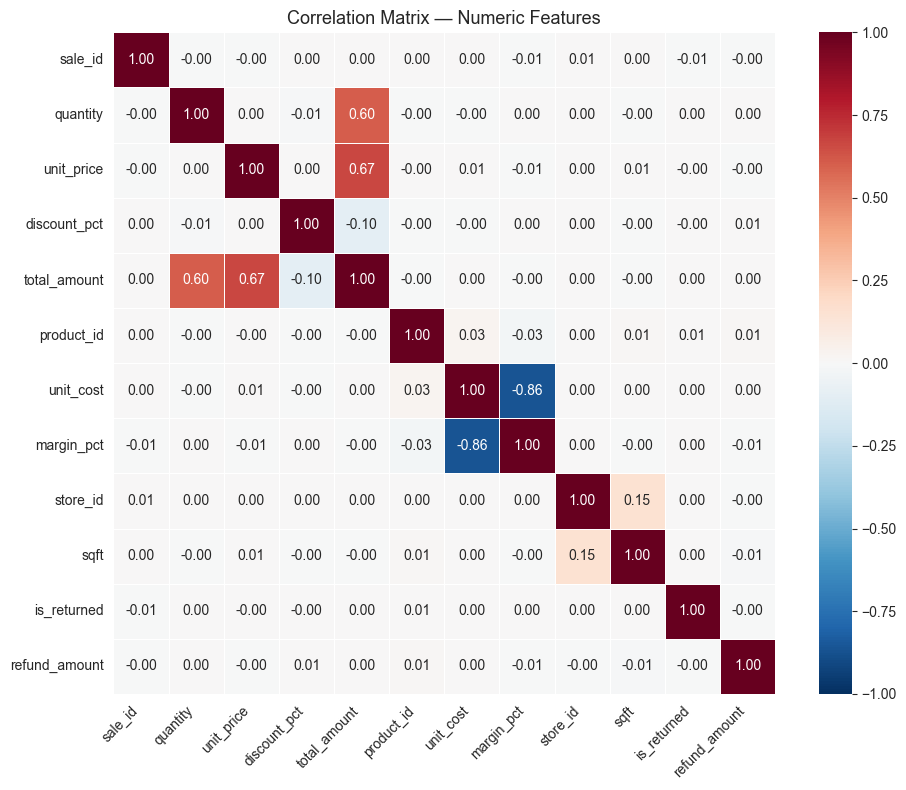

Saved → reports/correlation_heatmap.png


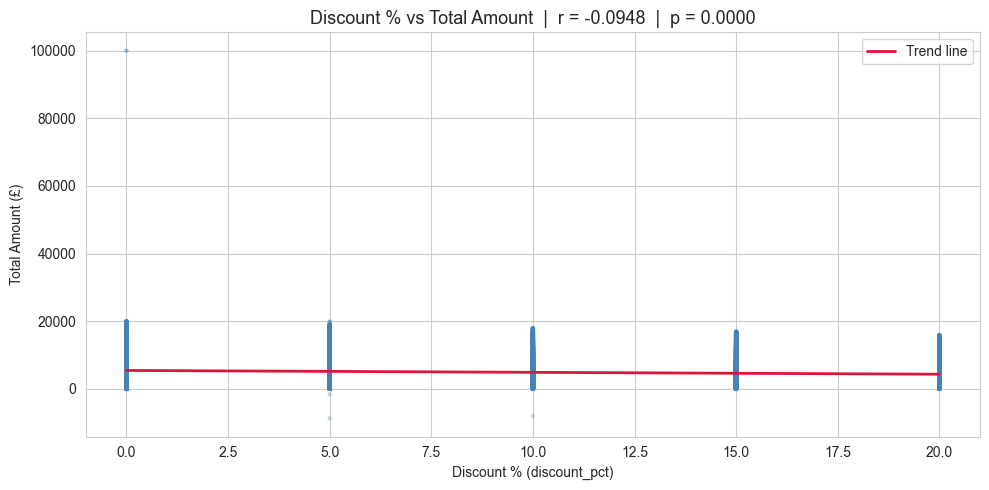

Saved → reports/q2_discount_correlation.png

  Q2 — DISCOUNT IMPACT ANSWER
  Pearson r  : -0.0948
  P-value    : 0.0000
  Significant: Yes (α = 0.05)
  Sample size: 50,243

  ⚠ NEGATIVE CORRELATION DETECTED
  Higher discounts correlate with LOWER revenue totals.
  The company is losing margin for nothing.

Strongest correlations across all features:
  unit_cost ↔ margin_pct: r=-0.863 (STRONG ↓)
  unit_price ↔ total_amount: r=0.670 (MODERATE ↑)
  quantity ↔ total_amount: r=0.603 (MODERATE ↑)


In [15]:
# ── Cell 6: Q2 — Discount Impact (Pearson Correlation) ───────────────────
# Does offering higher discounts actually drive higher sales volume?
# Pearson correlation between discount_pct and total_amount.
# A negative r means higher discounts → lower revenue totals.

engine.correlation()

if 'correlation' in engine.results:
    # ── Heatmap: full correlation matrix ─────────────────────────────────
    corr_df = pd.DataFrame(engine.results['correlation']['matrix'])

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr_df,
        annot=True, fmt='.2f',
        cmap='RdBu_r', vmin=-1, vmax=1,
        square=True, linewidths=0.5,
        ax=ax
    )
    ax.set_title('Correlation Matrix — Numeric Features', fontsize=13)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'correlation_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/correlation_heatmap.png')

    # ── Scatter: discount_pct vs total_amount ─────────────────────────────
    if 'discount_pct' in analysis_df.columns and 'total_amount' in analysis_df.columns:
        from scipy import stats

        clean = analysis_df[['discount_pct', 'total_amount']].dropna()
        r, p_value = stats.pearsonr(clean['discount_pct'], clean['total_amount'])

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.scatter(
            clean['discount_pct'],
            clean['total_amount'],
            alpha=0.3,
            color='steelblue',
            edgecolors='none',
            s=10
        )

        # Trend line
        m, b = np.polyfit(clean['discount_pct'], clean['total_amount'], 1)
        x_line = np.linspace(clean['discount_pct'].min(), clean['discount_pct'].max(), 100)
        ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2, label='Trend line')

        ax.set_title(
            f'Discount % vs Total Amount  |  r = {r:.4f}  |  p = {p_value:.4f}',
            fontsize=13
        )
        ax.set_xlabel('Discount % (discount_pct)')
        ax.set_ylabel('Total Amount (£)')
        ax.legend()
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / 'q2_discount_correlation.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved → reports/q2_discount_correlation.png')

        # ── Answer ────────────────────────────────────────────────────────
        print('\n' + '=' * 55)
        print('  Q2 — DISCOUNT IMPACT ANSWER')
        print('=' * 55)
        print(f'  Pearson r  : {r:.4f}')
        print(f'  P-value    : {p_value:.4f}')
        print(f'  Significant: {"Yes" if p_value < 0.05 else "No"} (α = 0.05)')
        print(f'  Sample size: {len(clean):,}')
        print()
        if r < 0:
            print('  ⚠ NEGATIVE CORRELATION DETECTED')
            print('  Higher discounts correlate with LOWER revenue totals.')
            print('  The company is losing margin for nothing.')
        else:
            print('  ✅ POSITIVE CORRELATION')
            print('  Higher discounts correlate with HIGHER revenue totals.')
        print('=' * 55)

    # ── Strongest pairs summary ───────────────────────────────────────────
    print('\nStrongest correlations across all features:')
    for pair in engine.results['correlation']['strong_pairs'][:5]:
        direction = '↑' if pair['direction'] == 'positive' else '↓'
        print(f"  {pair['col_a']} ↔ {pair['col_b']}: r={pair['correlation']:.3f} ({pair['strength']} {direction})")

2026-05-17 00:19:16 [INFO] AnomalyDetector initialised — 50,243 rows to scan
2026-05-17 00:19:16 [INFO] [ANOMALY] total_amount: IQR=717 | Z-score=275 | Confirmed=275
2026-05-17 00:19:16 [INFO] [ANOMALY] unit_price: IQR=0 | Z-score=0 | Confirmed=0
2026-05-17 00:19:17 [INFO] [ANOMALY] discount_pct: IQR=0 | Z-score=0 | Confirmed=0
2026-05-17 00:19:17 [INFO] [ANOMALY] Scan complete: 275 confirmed anomaly rows found
2026-05-17 00:19:17 [INFO] [ANOMALY] 275 anomaly rows saved: /Users/samueladesina/retail-eda-analysis/reports/anomalies.csv


  Q3 — ANOMALY DETECTION SUMMARY
      column  iqr_flagged  zscore_flagged  confirmed_anomalies  anomaly_pct
total_amount          717             275                  275         0.55
  unit_price            0               0                    0         0.00
discount_pct            0               0                    0         0.00

Total confirmed anomaly rows: 275
Saved → reports/anomalies.csv


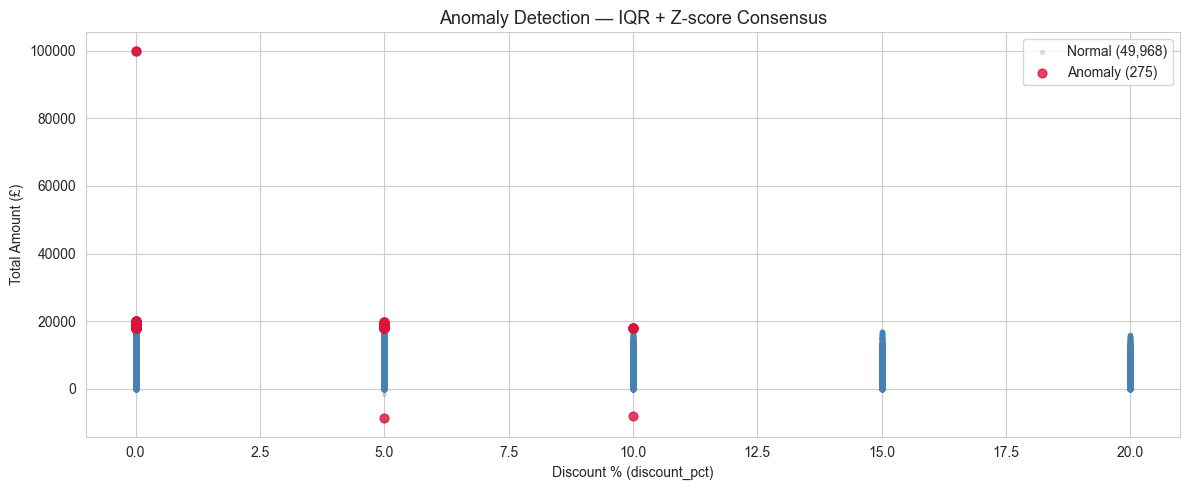

Saved → reports/q3_anomalies.png

Sample anomaly transactions:
 sale_date        store_name    category  total_amount  unit_price  discount_pct
2022-01-07   Atlanta Central    Clothing      19354.00     1935.40           0.0
2022-01-08           LA Main        Home      18654.60     1865.46           0.0
2022-01-13   Atlanta Central    Clothing      18951.10     1895.11           0.0
2022-01-19    Toronto Centre    Clothing      18622.10     1862.21           0.0
2022-01-21 Downtown Flagship        Home      19588.60     1958.86           0.0
2022-01-29           LA Main      Beauty      17945.64     1993.96           0.0
2022-01-30       Seattle Hub    Clothing      18086.40     1808.64           0.0
2022-01-31   Midtown Express Electronics      18540.20     1854.02           0.0
2022-01-31           LA Main        Home      19212.70     1921.27           0.0
2022-02-05 Downtown Flagship    Clothing      99999.99     1369.19           0.0


In [16]:
# ── Cell 8: Q3 — Anomaly Detection ───────────────────────────────────────
# Which transactions are statistically unusual?
# IQR + Z-score consensus — flagged by BOTH methods only.

detector = AnomalyDetector(analysis_df)
detector.run(columns=['total_amount', 'unit_price', 'discount_pct'])
detector.save_anomalies()

# ── Summary table ─────────────────────────────────────────────────────────
print('=' * 55)
print('  Q3 — ANOMALY DETECTION SUMMARY')
print('=' * 55)
print(detector.summary().to_string(index=False))
print(f'\nTotal confirmed anomaly rows: {len(detector.confirmed):,}')
print(f'Saved → reports/anomalies.csv')

# ── Chart: Anomalies vs Normal transactions ───────────────────────────────
if len(detector.confirmed) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))

    # Normal transactions in blue
    normal = analysis_df[~analysis_df.index.isin(detector.confirmed.index)]
    ax.scatter(
        normal['discount_pct'],
        normal['total_amount'],
        alpha=0.2,
        color='steelblue',
        s=8,
        label=f'Normal ({len(normal):,})'
    )

    # Anomalies in red
    ax.scatter(
        detector.confirmed['discount_pct'],
        detector.confirmed['total_amount'],
        alpha=0.8,
        color='crimson',
        s=40,
        label=f'Anomaly ({len(detector.confirmed):,})',
        zorder=5
    )

    ax.set_title('Anomaly Detection — IQR + Z-score Consensus', fontsize=13)
    ax.set_xlabel('Discount % (discount_pct)')
    ax.set_ylabel('Total Amount (£)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'q3_anomalies.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/q3_anomalies.png')

    # ── Preview anomaly rows ──────────────────────────────────────────────
    print('\nSample anomaly transactions:')
    print(detector.confirmed[['sale_date', 'store_name', 'category',
                               'total_amount', 'unit_price', 'discount_pct']]
          .head(10)
          .to_string(index=False))

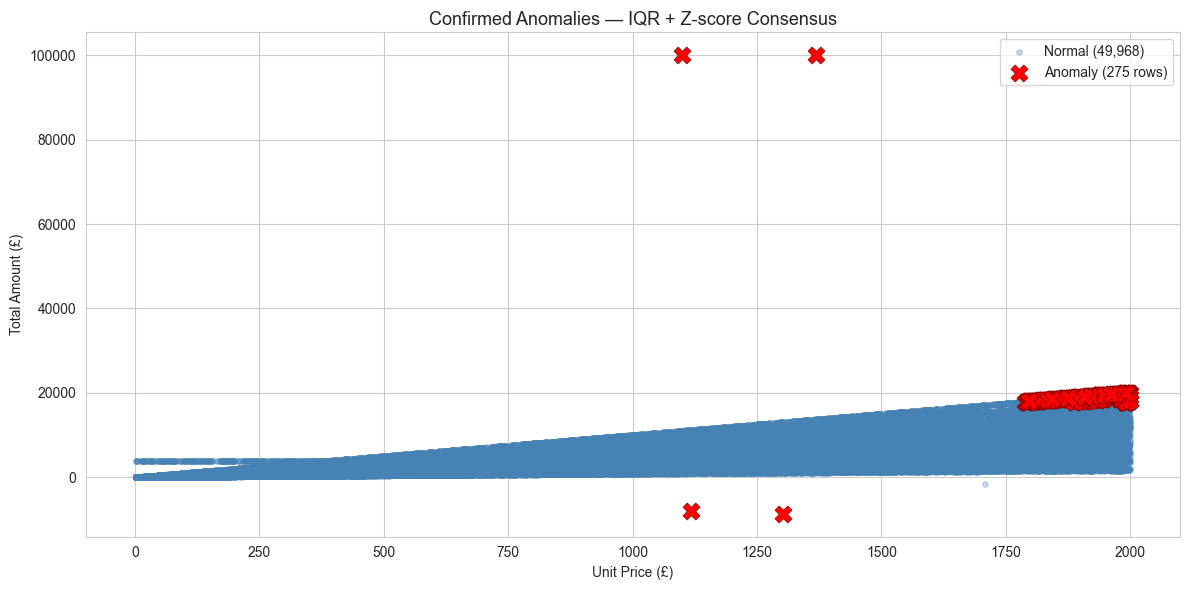

Saved → reports/q3_anomalies_plot.png


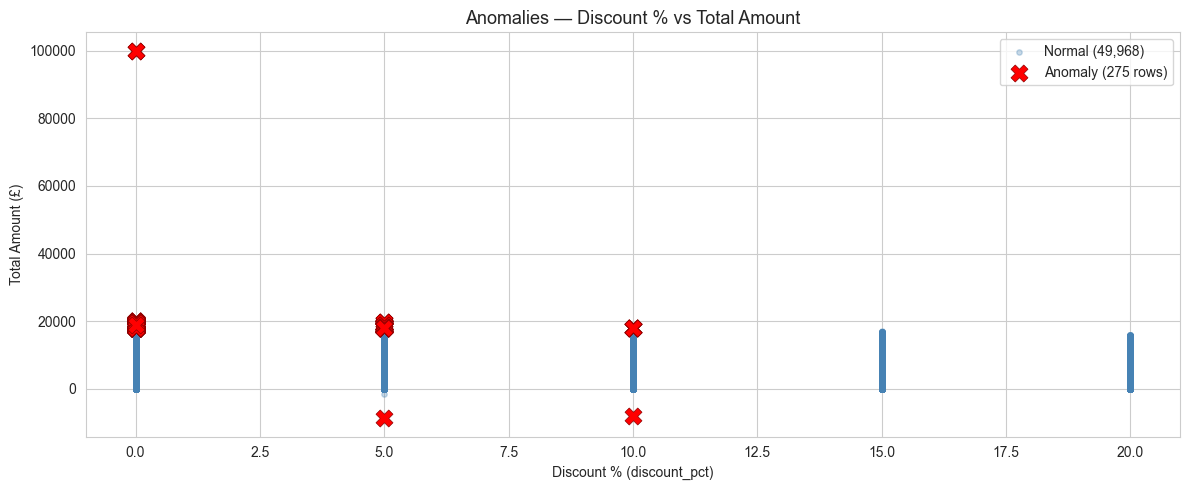

Saved → reports/q3_anomalies_discount.png

Anomaly rows — top 10:
 sale_date        store_name    category  total_amount  unit_price  discount_pct
2022-01-07   Atlanta Central    Clothing      19354.00     1935.40           0.0
2022-01-08           LA Main        Home      18654.60     1865.46           0.0
2022-01-13   Atlanta Central    Clothing      18951.10     1895.11           0.0
2022-01-19    Toronto Centre    Clothing      18622.10     1862.21           0.0
2022-01-21 Downtown Flagship        Home      19588.60     1958.86           0.0
2022-01-29           LA Main      Beauty      17945.64     1993.96           0.0
2022-01-30       Seattle Hub    Clothing      18086.40     1808.64           0.0
2022-01-31   Midtown Express Electronics      18540.20     1854.02           0.0
2022-01-31           LA Main        Home      19212.70     1921.27           0.0
2022-02-05 Downtown Flagship    Clothing      99999.99     1369.19           0.0


In [17]:
# ── Cell 9: Q3 — Visualise Anomalies ─────────────────────────────────────
# Normal rows = small blue dots
# Anomaly rows = large red X marks
# We plot total_amount vs unit_price — most revealing for retail anomalies

if len(detector.confirmed) > 0:
    x_col = 'unit_price'
    y_col = 'total_amount'

    # Separate normal and anomalous rows
    normal_mask  = ~analysis_df.index.isin(detector.confirmed.index)
    normal_rows  = analysis_df[normal_mask]
    anomaly_rows = analysis_df[~normal_mask]

    fig, ax = plt.subplots(figsize=(12, 6))

    # Normal rows — small transparent blue dots
    ax.scatter(
        normal_rows[x_col], normal_rows[y_col],
        c='steelblue', alpha=0.3, s=15, label=f'Normal ({len(normal_rows):,})'
    )

    # Anomaly rows — large red X markers
    ax.scatter(
        anomaly_rows[x_col], anomaly_rows[y_col],
        c='red', marker='X', s=150,
        label=f'Anomaly ({len(anomaly_rows):,} rows)',
        edgecolors='darkred', linewidths=0.5,
        zorder=5
    )

    ax.set_title('Confirmed Anomalies — IQR + Z-score Consensus', fontsize=13)
    ax.set_xlabel(x_col.replace('_', ' ').title() + ' (£)')
    ax.set_ylabel(y_col.replace('_', ' ').title() + ' (£)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'q3_anomalies_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/q3_anomalies_plot.png')

    # ── Second view: total_amount vs discount_pct ─────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.scatter(
        normal_rows['discount_pct'], normal_rows['total_amount'],
        c='steelblue', alpha=0.3, s=15, label=f'Normal ({len(normal_rows):,})'
    )
    ax.scatter(
        anomaly_rows['discount_pct'], anomaly_rows['total_amount'],
        c='red', marker='X', s=150,
        label=f'Anomaly ({len(anomaly_rows):,} rows)',
        edgecolors='darkred', linewidths=0.5,
        zorder=5
    )

    ax.set_title('Anomalies — Discount % vs Total Amount', fontsize=13)
    ax.set_xlabel('Discount % (discount_pct)')
    ax.set_ylabel('Total Amount (£)')
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / 'q3_anomalies_discount.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → reports/q3_anomalies_discount.png')

    # ── Anomaly preview ───────────────────────────────────────────────────
    print(f'\nAnomaly rows — top 10:')
    print(anomaly_rows[['sale_date', 'store_name', 'category',
                         'total_amount', 'unit_price', 'discount_pct']]
          .head(10)
          .to_string(index=False))

else:
    print('No confirmed anomalies found — data is clean!')

In [18]:
# ── Cell 10: Summary and Next Steps ──────────────────────────────────────
# Pull all results together into a final summary table.

print('=' * 62)
print('  SHOPSMART RETAIL GROUP — EDA COMPLETE')
print('=' * 62)

# ── Q1: Top category and store by revenue per sale ────────────────────────
top_category = (
    analysis_df.groupby('category')['total_amount']
    .mean()
    .idxmax()
)
top_category_val = (
    analysis_df.groupby('category')['total_amount']
    .mean()
    .max()
)

top_store = (
    analysis_df.groupby('store_name')['total_amount']
    .mean()
    .idxmax()
)
top_store_val = (
    analysis_df.groupby('store_name')['total_amount']
    .mean()
    .max()
)

# ── Q2: Strongest correlation ─────────────────────────────────────────────
from scipy import stats
clean = analysis_df[['discount_pct', 'total_amount']].dropna()
r, p_value = stats.pearsonr(clean['discount_pct'], clean['total_amount'])

top_pair = engine.results['correlation']['strong_pairs'][0] if engine.results['correlation']['strong_pairs'] else None

# ── Q3: Anomaly count ─────────────────────────────────────────────────────
anomaly_count = len(detector.confirmed)

# ── Print summary ─────────────────────────────────────────────────────────
print()
print(f"  {'Finding':<35} {'Value':<25} Action")
print('  ' + '-' * 75)
print(f"  {'Top category by avg revenue':<35} {top_category + f' (£{top_category_val:,.0f})':<25} Prioritise in merchandising")
print(f"  {'Top store by avg revenue':<35} {top_store + f' (£{top_store_val:,.0f})':<25} Use as benchmark")
print(f"  {'Discount ↔ Revenue (Pearson r)':<35} {str(round(r, 4)):<25} {'Review discount strategy' if r < 0 else 'Discounts driving revenue'}")
print(f"  {'Correlation significance':<35} {'Yes (p=' + str(round(p_value,4)) + ')':<25} Statistically confirmed")

if top_pair:
    pair_label = f"{top_pair['col_a']} ↔ {top_pair['col_b']} (r={top_pair['correlation']})"
    print(f"  {'Strongest feature correlation':<35} {pair_label:<25}")

print(f"  {'Anomaly rows confirmed':<35} {str(anomaly_count):<25} Review reports/anomalies.csv")
print()
print('=' * 62)
print()

# ── Next steps ────────────────────────────────────────────────────────────
print('  NEXT STEPS')
print('  ' + '-' * 40)
print('  1. Review anomalies.csv — are they data errors or real extremes?')
print('  2. Investigate underperforming stores flagged in Q1')
if r < 0:
    print('  3. ⚠ Reassess discount strategy — discounts are reducing revenue')
else:
    print('  3. Discounts appear effective — monitor margin impact')
print('  4. Use correlation findings for ML feature selection (Module 09)')
print('  5. Push all reports to GitHub')
print()

# ── Reports saved ─────────────────────────────────────────────────────────
print('  REPORTS SAVED TO reports/')
print('  ' + '-' * 40)
reports = [
    'dist_total_amount.png',
    'dist_unit_price.png',
    'dist_discount_pct.png',
    'q1_category_revenue_per_sale.png',
    'q1_store_revenue_per_sale.png',
    'q1_underperforming_stores.png',
    'correlation_heatmap.png',
    'q2_discount_correlation.png',
    'q3_anomalies_plot.png',
    'q3_anomalies_discount.png',
    'anomalies.csv',
    'analysis_report.txt',
]
for r_file in reports:
    exists = '✅' if (REPORTS_DIR / r_file).exists() else '❌'
    print(f'  {exists} {r_file}')

print()
print('=' * 62)

  SHOPSMART RETAIL GROUP — EDA COMPLETE

  Finding                             Value                     Action
  ---------------------------------------------------------------------------
  Top category by avg revenue         Clothing (£5,102)         Prioritise in merchandising
  Top store by avg revenue            Vancouver BC (£5,198)     Use as benchmark
  Discount ↔ Revenue (Pearson r)      -0.0948                   Review discount strategy
  Correlation significance            Yes (p=0.0)               Statistically confirmed
  Strongest feature correlation       unit_cost ↔ margin_pct (r=-0.863)
  Anomaly rows confirmed              275                       Review reports/anomalies.csv


  NEXT STEPS
  ----------------------------------------
  1. Review anomalies.csv — are they data errors or real extremes?
  2. Investigate underperforming stores flagged in Q1
  3. ⚠ Reassess discount strategy — discounts are reducing revenue
  4. Use correlation findings for ML feature sele